## Lab 11: Procesamiento de Datos para Machine Learning

Objetivo: Aplilcar las principales tecnicas de procesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML.

Problema: Se desea construir un modelo capax de predecir di un pasajero sobrevivio o no al hundimiento del Titanic

In [1]:
#importar librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

In [6]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

100%|██████████| 22.0k/22.0k [00:00<00:00, 173kB/s]

Extracting files...


In [7]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\arroy\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [9]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [10]:
dfTitanic.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

## Parte 1.Comprension del problema
Determinar si sobrevivieron al hundimiento del titanic con base en la informacion obtenida.

Survived

0 - No sobrevivieron
1 - Sobrevivio

In [11]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

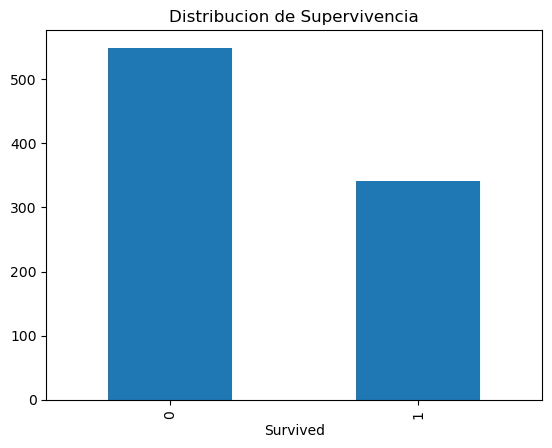

In [12]:
#Graficamos
dfTitanic["Survived"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de Supervivencia")
plt.show()

## Parte 2. Exploracion Inicial

In [13]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [17]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [18]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipotesis

creamos una matriz de correlacion para identificar la relacion lineal entre las variables. NO identifica la importancia de variable del modelo porque aun no de ejecuta.

In [21]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [22]:
corr = dfTitanic[variables_numericas].corr()

In [23]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


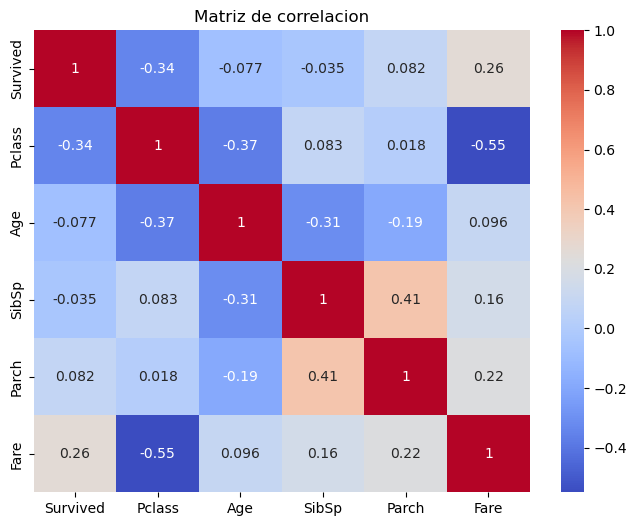

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

## Parte 4. Seleccion de variables predictoras y objetivas

x - variables que utilizan el modelo
y - variables que queremos predecir

In [27]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [28]:
#Definimos x  y
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [30]:
print(x.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [31]:
print(y.name)

Survived


## Parte 5. Tratamiento de los valores

Para simplificar el prceso realizaremos la imputacion de los datos antes de la separacion TRAIN/TEST.

In [32]:
#Revisamos las variables predictoras
x.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [35]:
x["Age"]= x["Age"].fillna(
    x["Age"].median()
)

C:\Users\arroy\AppData\Local\Temp\ipykernel_10168\597591072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"]= x["Age"].fillna(


In [37]:
x["Embarked"]= x["Embarked"].fillna(
    x["Embarked"].mode()[0]
)

C:\Users\arroy\AppData\Local\Temp\ipykernel_10168\1377262238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Embarked"]= x["Embarked"].fillna(


In [38]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Parte 6. Escalado de los datos
Los algoritmos no entienden texto. Se deben convertir en variables categoricas en variables numericas.

In [39]:
x = pd.get_dummies(
    x,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [40]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Parte 7. Particionar datos.

NO debemos entrenar ni evaluar utilizando los mismos datos, si no el algoritmo va a recordar.

La recomendacion es:

Emtrenamiento 80%, y Pruebas 20%

In [41]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42
)

In [42]:
print ("Entrenamiento:", x_train.shape)

Entrenamiento: (712, 8)


In [43]:
print ("Prueba:", y_test.shape)

Prueba: (179,)


## Parte 8. Escalado de los datos.

Las variables numericas tiene valores distintos. El escalado evita que una variable domine mas que otra.

In [44]:
columnas_numericas = [
    "Age", 
    "Fare",
    "SibSp",
    "Parch"
]

In [45]:
x_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [47]:
scaler = StandardScaler()
x_train[columnas_numericas] = scaler.fit_transform(
    x_train[columnas_numericas]
)
x_test[columnas_numericas] = scaler.transform(
    x_test[columnas_numericas]
)

In [48]:
x_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17,1.746418e-17,2.245395e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01,-4.707224e-01,-4.793416e-01
25%,-5.542135e-01,-4.748670e-01,-4.707224e-01,-4.793416e-01
50%,-9.263364e-02,-3.491435e-01,-4.707224e-01,-4.793416e-01
75%,4.458762e-01,-4.017244e-02,3.799232e-01,-4.793416e-01
max,3.907725e+00,9.237724e+00,6.334442e+00,7.104908e+00


## Parte 9. Entrenamiento de los datos.

Usaremos un arbol de decision para clasificar los registros.

In [49]:
modelo = DecisionTreeClassifier(
    max_depth = 4,
    random_state = 42
)

In [50]:
modelo.fit(
    x_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

## Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo

In [51]:
predicciones = modelo.predict(
    x_test
)

In [52]:
pd.DataFrame({
    "Real: ": y_test,
    "Prediccion: ": predicciones
}).head(15)

,Real:,Prediccion:
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Parte 11. Evaluacion del modelo

El accuracy determinar el porcentaje de predicciones correctas realizadas por el modelo

In [53]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [54]:
print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.7989


|Accuracy| Interpretacion|
|--------|---------------|
|50% | Adivina |
|60%-70% | Aceptable / Basico |
|70%-80% | Bueno |
|80%-90% | Muy Bueno |
|>90% | Excelente ( posible sobreajuste)|


## Parte 12. Importancia de las variables

Analizar las varibles mas relevantes para el algoritmo.

In [56]:
importancias = pd.DataFrame({
    "Variable" : x_train.columns,
    "Importancias" : modelo.feature_importances_ #que variable es importante para el modelo
})

In [60]:
importancias.sort_values(
    by="Importancias",
    ascending=False
)

,Variable,Importancias
5,Sex_male,0.579608
0,Pclass,0.200498
4,Fare,0.081064
1,Age,0.078872
2,SibSp,0.046059
7,Embarked_S,0.013900
3,Parch,0.000000
6,Embarked_Q,0.000000
